# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Azizah Khusnul Fauziah
- **Email:** azizahkhusnulf@gmail.com
- **ID Dicoding:** azizah_khf

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Kapan waktu puncak (peak hours) penyewaan sepeda terjadi, dan bagaimana perbedaannya antara hari kerja (workingday) dan hari libur/akhir pekan?
- Pertanyaan 2: Bagaimana tingkat pertumbuhan penyewaan sepeda dari tahun 2011 ke tahun 2012? Segmen pelanggan mana (casual vs registered) yang tumbuh paling pesat?

## Import Semua Packages/Library yang Digunakan

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
day_df = pd.read_csv("/content/drive/MyDrive/Azizah's Learning/ID Camp/proyek-analisis-data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [36]:
hour_df = pd.read_csv("/content/drive/MyDrive/Azizah's Learning/ID Camp/proyek-analisis-data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

Menilai data day_df

In [37]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Terdapat kesalahan tipe data pada kolom dteday. Harusnya kolom tersebut direpresentasikan sebagai tipe data datetime

In [38]:
#Melihat Duplikasi Data
print("Jumlah duplikasi: ", day_df.duplicated().sum())
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai data hour_df

In [39]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Terdapat kesalahan tipe data pada kolom dteday. Harusnya kolom tersebut direpresentasikan sebagai tipe data datetime

In [40]:
#Melihat Duplikasi Data
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Cleaning Data

In [41]:
#Mengganti tipe data menjadi datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])

Mengganti tipe data dteday dari object menjadi datetime pada tabel day_df

In [42]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

tipe data pada kolom dteday telah berhasil diubah menjadi datetime

In [43]:
#Mengganti tipe data menjadi datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
    hour_df[column] = pd.to_datetime(hour_df[column])

Mengganti tipe data dteday dari object menjadi datetime pada tabel hour_df

In [44]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

tipe data pada kolom dteday telah berhasil diubah menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...

In [45]:
#Rangkumann Parameter Statistik
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [46]:
#Membuat dictionary untuk pemetaan nilai
mapping_workingday = {
    1: "Hari Kerja",
    0: "Akhir Pekan"
}

mapping_yr = {
    0: "2011",
    1: "2012"
}

#Menerapkan pemetaan tersebut ke dalam kolom yang sesuai menggunakan .map()
hour_df['workingday'] = hour_df['workingday'].map(mapping_workingday)
hour_df['yr'] = hour_df['yr'].map(mapping_yr)

#Menampilkan 5 baris pertama untuk mengecek apakah hasilnya sudah berubah
hour_df[['workingday', 'yr']].head()

,workingday,yr
0,Akhir Pekan,2011
1,Akhir Pekan,2011
2,Akhir Pekan,2011
3,Akhir Pekan,2011
4,Akhir Pekan,2011


In [47]:
hour_df["workingday"].unique()

array(['Akhir Pekan', 'Hari Kerja'], dtype=object)

In [48]:
hour_df["yr"].unique()

array(['2011', '2012'], dtype=object)


*  **Proses Pemetaan (Mapping):** Kode diatas melakukan transformasi data pada kolom workingday dan yr. Nilai asli yang berupa angka (numerik) diubah menjadi label teks (kategorikal) agar lebih informatif. Pada kolom workingday, nilai 1 diubah menjadi "Hari Kerja" dan 0 menjadi "Akhir Pekan". Sedangkan pada kolom yr, nilai 0 dipetakan menjadi tahun "2011" dan 1 menjadi "2012".
*   **Tujuan Transformasi:** Perubahan ini dilakukan untuk mempermudah proses Manual Grouping dan pembacaan data. Dengan mengubah angka menjadi label deskriptif, hasil analisis dan visualisasi nantinya akan lebih mudah dipahami oleh audiens karena tidak perlu lagi menerjemahkan arti angka-angka tersebut secara manual.



In [49]:
#Mendefinisikan batas interval
bins = [-1, 5, 10, 15, 18, 23]

#Mendefinisikan label
labels = ["Dini Hari", "Pagi", "Siang", "Sore", "Malam"]

#Melakukan binning ke dataset hour_df
hour_df["waktu_hari"] = pd.cut(hour_df["hr"], bins=bins, labels=labels)

In [50]:
hour_df["waktu_hari"].unique()

['Dini Hari', 'Pagi', 'Siang', 'Sore', 'Malam']
Categories (5, object): ['Dini Hari' < 'Pagi' < 'Siang' < 'Sore' < 'Malam']



*  **Penerapan Teknik Binning:** Kode tersebut mengimplementasikan teknik Binning untuk memecah data angka (kolom hr atau jam) ke dalam beberapa interval kelompok waktu.
*   **Penentuan Batas (Bins) dan Kategori (Labels):** Variabel bins dibuat untuk menentukan titik batas antar interval, sedangkan labels mendefinisikan nama rentangnya. Berdasarkan aturan pada kode yang telah dibuat, jam 0-5 dikelompokkan sebagai "Dini Hari", >5-10 sebagai "Pagi", >10-15 sebagai "Siang", >15-18 sebagai "Sore", dan >18-23 sebagai "Malam".
*  **Eksekusi Transformasi Data:** Menggunakan fungsi pd.cut() dari library Pandas, sistem secara otomatis mengevaluasi setiap nilai pada kolom hr, menempatkannya ke dalam interval bins yang tepat, lalu menyimpan label hasilnya ke dalam kolom baru bernama waktu_hari.
*   **Tujuan:** Transformasi ini sangat krusial untuk mempermudah analisis tren. Alih-alih menganalisis pergerakan data pada 24 titik jam yang berbeda secara terpisah, pengelompokan ini memungkinkan kita melihat cluster waktu puncak (peak hours) secara makro, seperti membandingkan performa periode "Sore" dengan "Pagi".




Setelah proses transformasi dilakukan, hasil akhir pada dataset adalah sebagai berikut:

In [51]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,waktu_hari
0,1,2011-01-01,1,2011,1,0,0,6,Akhir Pekan,1,0.24,0.2879,0.81,0.0,3,13,16,Dini Hari
1,2,2011-01-01,1,2011,1,1,0,6,Akhir Pekan,1,0.22,0.2727,0.80,0.0,8,32,40,Dini Hari
2,3,2011-01-01,1,2011,1,2,0,6,Akhir Pekan,1,0.22,0.2727,0.80,0.0,5,27,32,Dini Hari
3,4,2011-01-01,1,2011,1,3,0,6,Akhir Pekan,1,0.24,0.2879,0.75,0.0,3,10,13,Dini Hari
4,5,2011-01-01,1,2011,1,4,0,6,Akhir Pekan,1,0.24,0.2879,0.75,0.0,0,1,1,Dini Hari


In [52]:
#Rangkumann Parameter Statistik
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [53]:
#Membuat dictionary untuk pemetaan nilai
mapping_workingday = {
    1: "Hari Kerja",
    0: "Akhir Pekan"
}

mapping_yr = {
    0: "2011",
    1: "2012"
}

#Menerapkan pemetaan tersebut ke dalam kolom yang sesuai menggunakan .map()
day_df['workingday'] = day_df['workingday'].map(mapping_workingday)
day_df['yr'] = day_df['yr'].map(mapping_yr)

#Menampilkan 5 baris pertama untuk mengecek apakah hasilnya sudah berubah
day_df[['workingday', 'yr']].head()

,workingday,yr
0,Akhir Pekan,2011
1,Akhir Pekan,2011
2,Hari Kerja,2011
3,Hari Kerja,2011
4,Hari Kerja,2011


Proses mapping pada tabel day_df menggunakan pendekatan yang sama dengan yang telah dilakukan pada tabel hour_df

In [54]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,2011,1,0,6,Akhir Pekan,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,2011,1,0,0,Akhir Pekan,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,2011,1,0,1,Hari Kerja,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,2011,1,0,2,Hari Kerja,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,2011,1,0,3,Hari Kerja,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [55]:
#Mencari rata-rata jumlah penyewaan sepeda pada setiap jam, dipisahkan antara hari kerja dan hari libur
peak_hours = hour_df.groupby(["workingday", "hr"])["cnt"].mean().reset_index().sort_values("cnt", ascending=False)
peak_hours.head()

,workingday,hr,cnt
41,Hari Kerja,17,525.290581
42,Hari Kerja,18,492.226908
32,Hari Kerja,8,477.006048
13,Akhir Pekan,13,372.731602
12,Akhir Pekan,12,366.259740


In [56]:
#Menghitung total casual dan registered per tahun.
yoy_df = day_df.groupby("yr")[["casual", "registered"]].sum().reset_index()
yoy_df.head()

,yr,casual,registered
0,2011,247252,995851
1,2012,372765,1676811


In [57]:
#Menghitung total penyewaan per tahun
yoy_df["total"] = yoy_df["casual"] + yoy_df["registered"]
yoy_df.head()

,yr,casual,registered,total
0,2011,247252,995851,1243103
1,2012,372765,1676811,2049576


## Visualization & Explanatory Analysis

### **Pertanyaan 1**: Kapan waktu puncak (peak hours) penyewaan sepeda terjadi, dan bagaimana perbedaannya antara hari kerja (workingday) dan hari libur/akhir pekan?


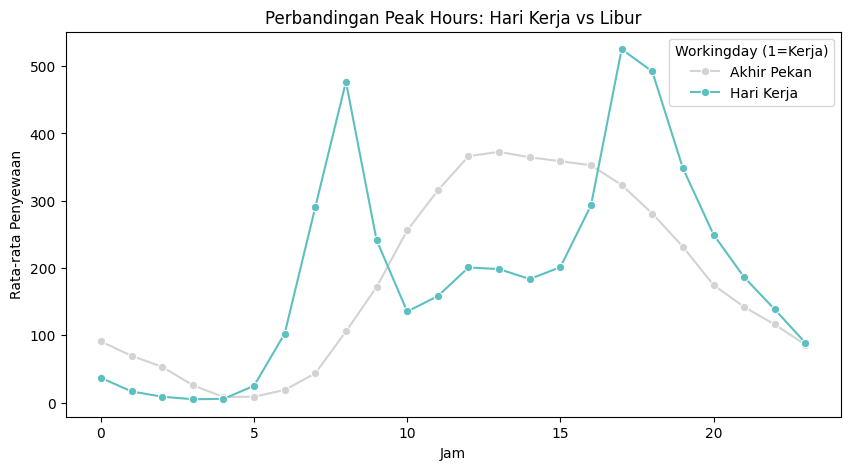

In [58]:
#Membuat Perbandingan Peak Hours dengan Line Chart
peak_hours = (
    hour_df
    .groupby(["workingday","hr"])["cnt"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=peak_hours,
    x="hr",
    y="cnt",
    hue="workingday",
    marker="o",
    palette={
        "Hari Kerja": "#5DC0C0",   # biru
        "Akhir Pekan": "#D3D3D3"   # abu
    }
)

plt.title("Perbandingan Peak Hours: Hari Kerja vs Libur")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.legend(title="Workingday (1=Kerja)")
plt.show()

1.   **Pola Hari Kerja (Garis Teal)**
      
      Lonjakan pertama terjadi pada pukul 08:00 pagi, di mana rata-rata penyewaan mendekati angka 500 dan lonjakan kedua (yang merupakan titik tertinggi) terjadi antara pukul 17:00 hingga 18:00 sore, menyentuh angka di atas 500 penyewaan.
      
      Pola ini sangat identik dengan mobilitas komuter (pekerja atau pelajar). Orang-orang menggunakan layanan penyewaan (kemungkinan sepeda atau skuter listrik) untuk berangkat kerja/sekolah di pagi hari, dan menggunakannya kembali untuk pulang di sore hari. Di sela-sela jam kerja (pukul 10:00 - 15:00), penyewaan menurun tajam karena mayoritas orang sedang beraktivitas di dalam gedung.
2.   **Pola Akhir Pekan (Garis Abu)**
      
      Jumlah penyewaan baru mulai naik perlahan sejak jam 08:00 pagi. Tingkat penyewaan tertinggi terjadi dan bertahan pada rentang pukul 12:00 siang hingga 15:00 sore (berada di sekitar angka 350 - 380 rata-rata penyewaan).

      Pola ini mencerminkan penggunaan untuk rekreasi, olahraga santai, atau pariwisata. Karena tidak terikat jadwal masuk kerja atau sekolah, pengguna cenderung menyewa di siang hari untuk berjalan-jalan santai, dan penggunaannya berangsur turun menjelang malam.



/tmp/ipython-input-320/2108977104.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = hour_df.pivot_table(


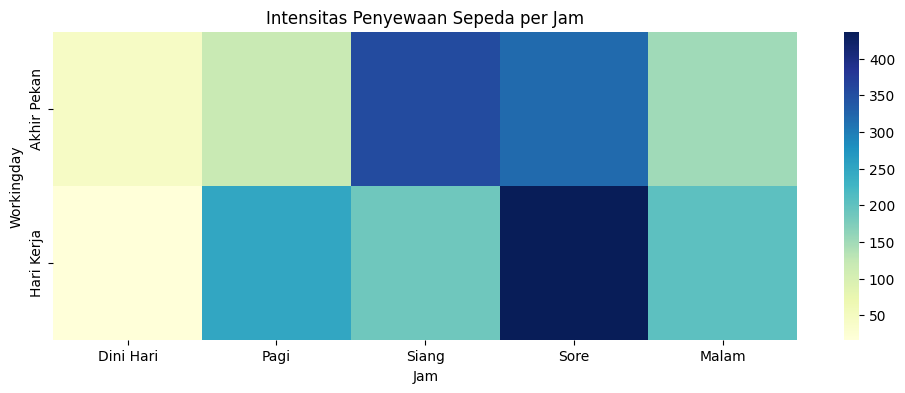

In [59]:
#Melihat Intensitas Penyewaan Menggunakan Heatmap
heatmap_data = hour_df.pivot_table(
    values="cnt",
    index="workingday",
    columns="waktu_hari",
    aggfunc="mean"
)

plt.figure(figsize=(12,4))

sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Intensitas Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Workingday")
plt.show()

1. **Analisis Hari Kerja (Baris Bawah)**
    
      **Konsentrasi Tertinggi di Waktu Sore:** Kotak paling gelap di seluruh diagram berada pada perpotongan Hari Kerja dan waktu Sore. Ini menunjukkan bahwa aktivitas penyewaan paling intens terjadi saat orang-orang pulang kerja/sekolah.
      
      **Intensitas Tinggi di Pagi Hari:** Kotak pada waktu Pagi juga berwarna biru cukup pekat (meskipun tidak sepekat sore), yang kembali mengonfirmasi tingginya aktivitas keberangkatan di pagi hari.
      
      **Penurunan di Siang Hari:** Terlihat bahwa warna pada periode siang hari cenderung memudar menjadi biru muda, yang menunjukkan adanya penurunan aktivitas penyewaan sepeda. Hal ini mengindikasikan bahwa di antara jam sibuk pagi dan sore, sepeda lebih banyak dalam kondisi terparkir dan tidak digunakan.

2. **Analisis Akhir Pekan (Baris Atas)**
      
      **Konsentrasi Tertinggi di Siang hingga Sore:** Berbeda dengan hari kerja, warna biru tua yang pekat bergeser ke waktu Siang. Intensitas ini juga masih bertahan cukup tinggi hingga waktu Sore.
      
      **Pagi yang Sepi:** Waktu Pagi di akhir pekan berwarna hijau muda pucat. Ini menunjukkan sedikitnya minat orang untuk menyewa sepeda di pagi hari saat libur, kemungkinan karena banyak yang baru memulai aktivitas rekreasi menjelang siang.

3. **Dini Hari dan Malam (Kesamaan Pola)**
      
      Pada kedua hari (baik hari kerja maupun akhir pekan), waktu Dini Hari memiliki warna paling terang (kuning pucat), yang berarti intensitas penyewaan hampir mendekati nol. Waktu Malam juga menunjukkan aktivitas yang cukup rendah, ditandai dengan warna biru muda terang.

### **Pertanyaan 2:** Bagaimana tingkat pertumbuhan penyewaan sepeda dari tahun 2011 ke tahun 2012? Segmen pelanggan mana (casual vs registered) yang tumbuh paling pesat?

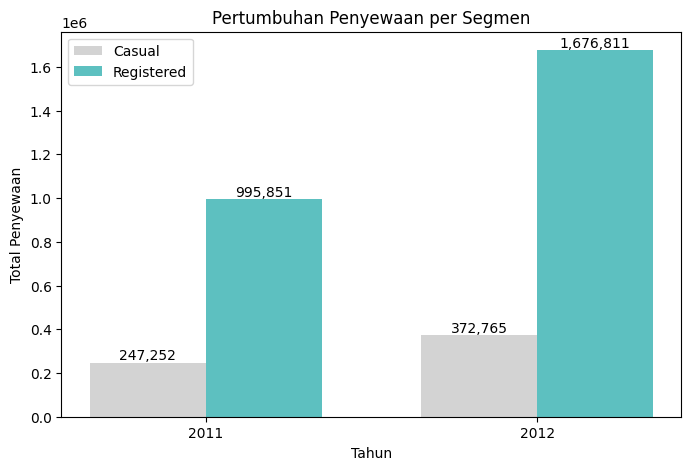

In [60]:
#Pertumbuhan Total Penyewaan Sepeda per Segmen
x = np.arange(len(yoy_df["yr"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x-width/2, yoy_df["casual"], width, label="Casual", color="#D3D3D3")
bars2 = ax.bar(x+width/2, yoy_df["registered"], width, label="Registered", color="#5DC0C0")

ax.bar_label(bars1, fmt='{:,.0f}')
ax.bar_label(bars2, fmt='{:,.0f}')

ax.set_xticks(x)
ax.set_xticklabels(yoy_df["yr"])
ax.set_title("Pertumbuhan Penyewaan per Segmen")
ax.set_xlabel("Tahun")
ax.set_ylabel("Total Penyewaan")

ax.legend()
plt.show()



*   **Dominasi Pengguna Terdaftar (Registered - Bar Teal)**
      
      Pengguna yang sudah terdaftar merupakan tulang punggung utama dari bisnis ini. Jumlah penyewaan oleh segmen ini jauh melampaui pengguna kasual. Terdapat peningkatan yang sangat pesat, dari 995.851 penyewaan di tahun 2011 menjadi 1.676.811 penyewaan di tahun 2012 (meningkat sekitar 68%).
*   **Pertumbuhan Pengguna Kasual (Casual - Bar Abu)**

      Meskipun proporsinya jauh lebih kecil dibandingkan pengguna terdaftar, segmen kasual juga menunjukkan tren positif.Penyewaan meningkat dari 247.252 di tahun 2011 menjadi 372.765 di tahun 2012 (meningkat sekitar 50%)
*   **Pertumbuhan Skala Bisnis**
      
      Lonjakan angka yang signifikan di tahun 2012 menandakan bahwa layanan penyewaan ini semakin populer dan diterima dengan baik oleh masyarakat secara umum.





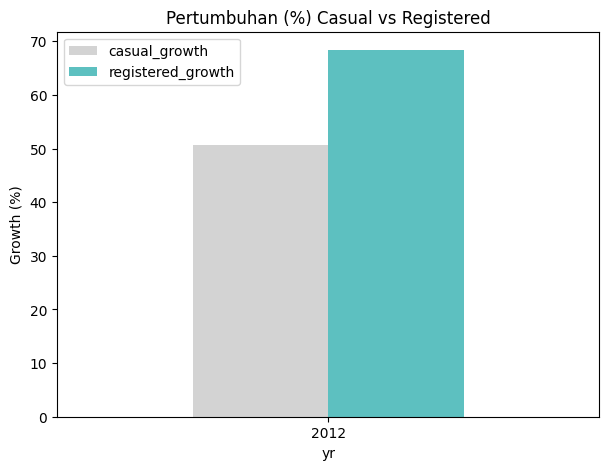

In [61]:
#kecepatan persentase pertumbuhan (growth rate)
yoy_df["casual_growth"] = yoy_df["casual"].pct_change()*100
yoy_df["registered_growth"] = yoy_df["registered"].pct_change()*100

growth_df = yoy_df.dropna()

growth_df.set_index("yr")[[
    "casual_growth",
    "registered_growth"
]].plot(kind="bar", figsize=(7,5), color=["#D3D3D3", "#5DC0C0"])

plt.title("Pertumbuhan (%) Casual vs Registered")
plt.ylabel("Growth (%)")
plt.xticks(rotation=0)
plt.show()



*   **Pertumbuhan Pengguna Terdaftar (Registered - Bar Teal)**
      
      Kelompok pengguna berlangganan memiliki tingkat pertumbuhan yang luar biasa pesat. Terlihat pada bar oranye bahwa pertumbuhannya nyaris menyentuh angka 70% (berada di kisaran 68%). Ini berarti jumlah penyewaan oleh pelanggan tetap melonjak lebih dari setengah lipat dibandingkan tahun sebelumnya.
*   **Pertumbuhan Pengguna Kasual (Casual - Bar Abu)**
      
      Pengguna biasa (tanpa akun/tidak berlangganan) juga menunjukkan pertumbuhan yang sangat solid. Bar biru menunjukkan peningkatan di kisaran angka 50%.

*   **Fase Ekspansi yang Sangat Sehat**
      
      Mengalami pertumbuhan 50% hingga 68% dalam satu tahun (Year-over-Year) adalah indikator bahwa layanan penyewaan sepeda sedang berada dalam tren positif dan adopsi pasar yang sangat kuat







## Analisis Lanjutan (Opsional)

**Kapan sepeda paling sering digunakan dalam sehari?**

/tmp/ipython-input-320/2030293003.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_segment = hour_df.groupby("waktu_hari")["cnt"].mean().reset_index()
/tmp/ipython-input-320/2030293003.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


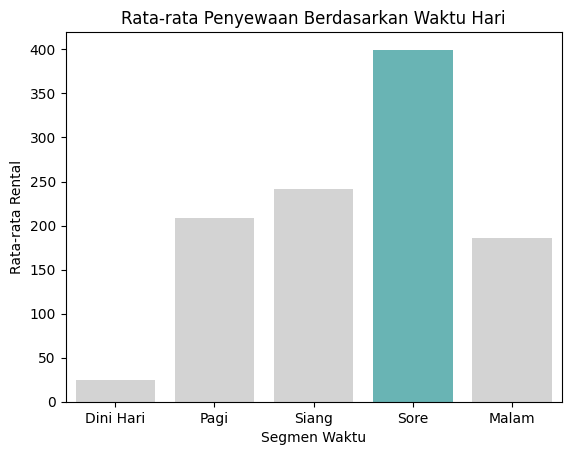

In [62]:
time_segment = hour_df.groupby("waktu_hari")["cnt"].mean().reset_index()

max_value = time_segment["cnt"].max()

colors = [
    "#5DC0C0" if value == max_value else "#D3D3D3"
    for value in time_segment["cnt"]
]

sns.barplot(
    data=time_segment,
    x="waktu_hari",
    y="cnt",
    palette=colors
)

plt.title("Rata-rata Penyewaan Berdasarkan Waktu Hari")
plt.xlabel("Segmen Waktu")
plt.ylabel("Rata-rata Rental")
plt.show()



*   **Sore (Puncak Tertinggi)**
      
      Batang grafik melonjak paling tinggi di waktu Sore, menyentuh angka rata-rata sekitar 400 penyewaan. Jika kita mengingat kembali diagram garis sebelumnya, tingginya angka di waktu sore ini sangat didorong oleh rutinitas orang pulang kerja/sekolah di hari biasa.
*   **Siang dan Pagi (Aktivitas Sedang - Tinggi)**
      
      Waktu Siang menjadi waktu tersibuk kedua (rata-rata sekitar 240-an penyewaan). Waktu Pagi menyusul di posisi ketiga (rata-rata sekitar 200-an penyewaan). Kedua waktu ini menunjukkan basis penggunaan yang solid, baik untuk komuter pagi maupun aktivitas rekreasi siang di akhir pekan.
*   **Malam (Mulai Menurun)**
      
      Saat memasuki waktu Malam, rata-rata penyewaan mulai turun (di bawah 200), menunjukkan aktivitas pengguna yang sudah mulai kembali ke rumah atau beristirahat.
*   **Dini Hari (Titik Terendah)**
      
      Batang grafik sangat pendek (hampir mendekati 0), yang sangat wajar karena minimnya mobilitas orang di jam tidur/tengah malam.





**Apakah sepeda lebih banyak digunakan saat kerja atau rekreasi?**

/tmp/ipython-input-320/892830734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=workingday_usage,


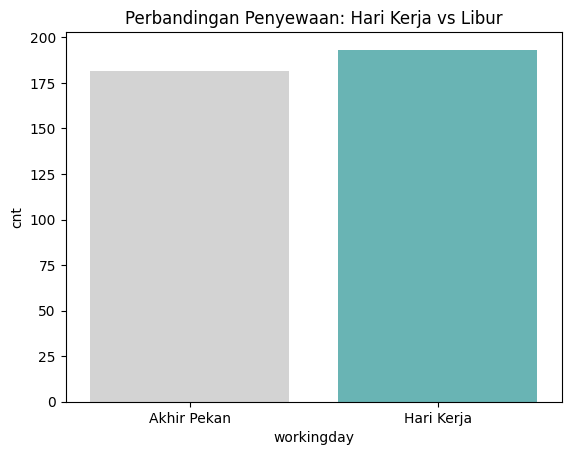

In [63]:
#rata-rata penyewaan sepeda
workingday_usage = hour_df.groupby("workingday")["cnt"].mean().reset_index()

sns.barplot(data=workingday_usage,
            x="workingday",
            y="cnt",
            palette={
              "Akhir Pekan": "#D3D3D3",
              "Hari Kerja": "#5DC0C0"
          }
            )

plt.title("Perbandingan Penyewaan: Hari Kerja vs Libur")
plt.show()



*   **Hari Kerja (Bar Teal)**
      
      Rata-rata penyewaan menunjukkan angka tertinggi, mendekati level 200 (sekitar 190-an penyewaan rata-rata).
*   **Akhir Pekan (Bar Abu)**
      
      Rata-rata penyewaan sedikit lebih rendah, berada di kisaran angka 175-180.
*   **Selisih Penggunaan**
      
      Meskipun Hari Kerja memimpin, perbedaan tingginya tidak terlalu ekstrem. Ini menunjukkan bahwa layanan sepeda tetap laku keras di kedua momen tersebut, hanya saja peruntukannya yang berbeda (seperti yang kita lihat pada grafik jam sibuk sebelumnya).






**Bagaimana perbedaan pola penyewaan sepeda antara pengguna casual (non-member) dan pengguna registered (member) berdasarkan Jam?**

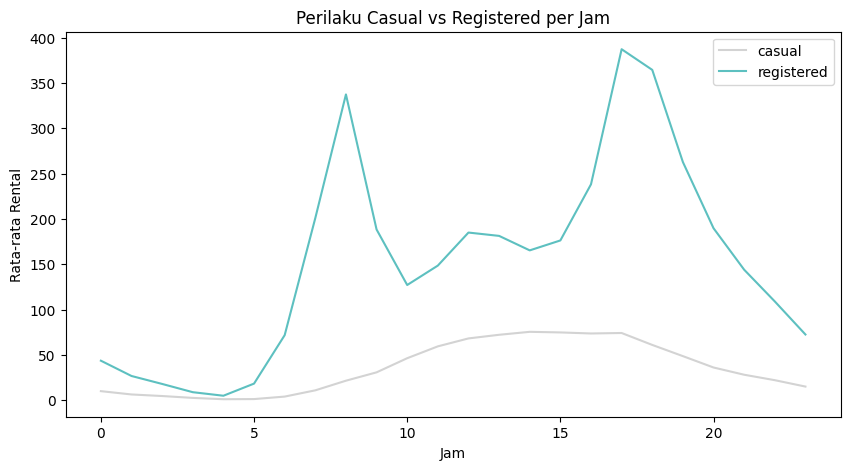

In [64]:
#rata-rata penyewaan per jam antara Pengguna Casual dan Pengguna Registered
hour_segment = hour_df.groupby("hr")[["casual","registered"]].mean()

hour_segment.plot(figsize=(10,5), color=["#D3D3D3", "#5DC0C0"])

plt.title("Perilaku Casual vs Registered per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Rental")
plt.show()



*   Pola Pengguna Registered

      Terjadi lonjakan signifikan pada pukul 08.00 pagi dengan rata-rata sekitar 340 penyewaan, serta lonjakan tertinggi pada pukul 17.00 sore yang hampir mencapai 400 penyewaan. Pola ini merepresentasikan dengan jelas waktu keberangkatan dan kepulangan kerja maupun sekolah. Setelah periode tersebut, terjadi penurunan penyewaan yang cukup drastis pada rentang pukul 09.00 hingga 16.00, yang mengindikasikan bahwa sebagian besar komuter sedang berada di dalam ruangan, seperti kantor atau kampus.
*   Pola Pengguna Casual

      Tidak terlihat adanya lonjakan penggunaan yang signifikan pada pagi maupun sore hari. Aktivitas penyewaan sepeda meningkat secara bertahap mulai pukul 09.00 dan mencapai puncaknya secara relatif stabil pada periode siang hingga sore hari, yaitu antara pukul 12.00 hingga 17.00.


## Conclusion



- **Conclusion pertanyaan 1: Kapan waktu puncak (peak hours) penyewaan sepeda terjadi, dan bagaimana perbedaannya antara hari kerja dan akhir pekan?**

  Waktu puncak penyewaan sepeda menunjukkan pola yang sangat berbeda antara hari kerja dan akhir pekan:
  - Pada **Hari Kerja**, penyewaan memuncak pada jam sibuk mobilitas (komuter), yaitu saat orang berangkat beraktivitas sekitar pukul **08:00 pagi** dan lonjakan paling tinggi terjadi saat pulang beraktivitas sekitar pukul **17:00 - 18:00 sore** (dengan rata-rata mencapai 490 - 525 penyewaan).
  - Pada **Akhir Pekan**, tren penyewaan lebih santai dan merata. Puncaknya terjadi di siang hari, khususnya pada rentang pukul **12:00 hingga 13:00 siang** (rata-rata 360 - 370 penyewaan). Hal ini mengindikasikan bahwa pada akhir pekan, sepeda lebih banyak dimanfaatkan untuk aktivitas rekreasi atau olahraga siang.

- **Conclusion pertanyaan 2: Bagaimana tingkat pertumbuhan penyewaan sepeda dari tahun 2011 ke tahun 2012? Segmen pelanggan mana yang tumbuh paling pesat?**
  
  Secara keseluruhan, tingkat penyewaan sepeda mengalami pertumbuhan (*Year-over-Year*) yang sangat positif. Total penyewaan melonjak pesat dari **1.243.103** pada tahun 2011 menjadi **2.049.576** pada tahun 2012 (tumbuh sekitar 64,8%).
  Jika dilihat lebih rinci berdasarkan segmen pelanggannya:
  - Pelanggan **Casual** (musiman) meningkat dari 247.252 menjadi 372.765 (tumbuh sekitar 50,7%).
  - Pelanggan **Registered** (terdaftar/berlangganan) meningkat pesat dari 995.851 menjadi 1.676.811 (tumbuh sekitar 68,3%).
  Oleh karena itu, dapat disimpulkan bahwa segmen pelanggan **Registered** adalah penyumbang jumlah sewa terbesar sekaligus segmen yang tumbuh paling pesat dibandingkan pelanggan Casual.

In [68]:
#Download Dataset yang sudah dianalisis
from google.colab import files

day_df.to_csv("day_df.csv", index=False)
files.download("day_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
#Download Dataset yang sudah dianalisis
from google.colab import files

hour_df.to_csv("hour_df.csv", index=False)
files.download("hour_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>